In [1]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from google.colab import files

uploaded = files.upload()

Saving dataset_raw(2).zip to dataset_raw(2).zip


In [3]:
import zipfile
import os

zip_path = "dataset_raw(2).zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset berhasil diekstrak!")
print("Isi folder:")
print(os.listdir(extract_path))

Dataset berhasil diekstrak!
Isi folder:
['dataset_raw']


In [4]:
data_path = "/content/dataset/dataset_raw"

print("Isi dataset:")
print(os.listdir(data_path))

Isi dataset:
['box', 'botol']


In [5]:
import os

DATA_DIR = "/content/dataset/dataset_raw"

print("Kelas:", os.listdir(DATA_DIR))

for class_name in sorted(os.listdir(DATA_DIR)):
    class_path = os.path.join(DATA_DIR, class_name)
    if os.path.isdir(class_path):
        files = os.listdir(class_path)
        print(f"{class_name}: {len(files)} gambar")

Kelas: ['box', 'botol']
botol: 50 gambar
box: 50 gambar


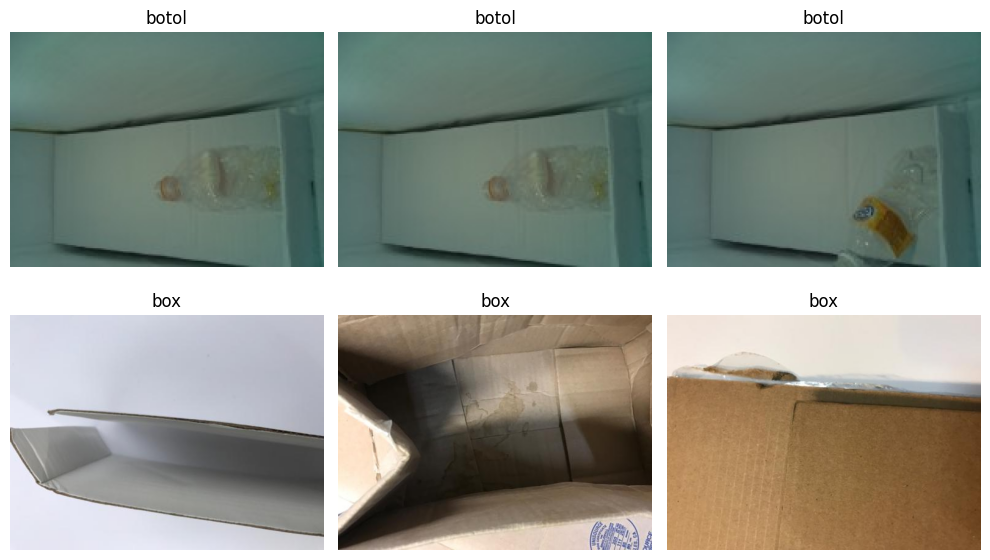

In [6]:
import matplotlib.pyplot as plt
from PIL import Image
import random

class_names = sorted([
    name for name in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, name))
])

plt.figure(figsize=(10, 6))

for i, class_name in enumerate(class_names):
    class_path = os.path.join(DATA_DIR, class_name)
    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
    ]

    for j in range(3):
        image_name = random.choice(image_files)
        image_path = os.path.join(class_path, image_name)

        image = Image.open(image_path)

        position = i * 3 + j + 1
        plt.subplot(2, 3, position)
        plt.imshow(image)
        plt.title(class_name)
        plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split

records = []

for class_name in class_names:
    class_path = os.path.join(DATA_DIR, class_name)

    for file_name in os.listdir(class_path):
        if file_name.lower().endswith(
            (".jpg", ".jpeg", ".png", ".bmp", ".webp")
        ):
            records.append({
                "path": os.path.join(class_path, file_name),
                "label": class_name
            })

df = pd.DataFrame(records)

print("Total gambar:", len(df))
print("\nJumlah tiap kelas:")
print(df["label"].value_counts())

Total gambar: 100

Jumlah tiap kelas:
label
botol    50
box      50
Name: count, dtype: int64


In [8]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

class_to_idx = {
    class_name: i
    for i, class_name in enumerate(class_names)
}

train_df["label_id"] = train_df["label"].map(class_to_idx)
val_df["label_id"] = val_df["label"].map(class_to_idx)
test_df["label_id"] = test_df["label"].map(class_to_idx)

print("Train      :", len(train_df))
print("Validation :", len(val_df))
print("Test       :", len(test_df))

print("\nMapping kelas:")
print(class_to_idx)

Train      : 70
Validation : 15
Test       : 15

Mapping kelas:
{'botol': 0, 'box': 1}


In [9]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

class_to_idx = {
    class_name: i
    for i, class_name in enumerate(class_names)
}

train_df["label_id"] = train_df["label"].map(class_to_idx)
val_df["label_id"] = val_df["label"].map(class_to_idx)
test_df["label_id"] = test_df["label"].map(class_to_idx)

print("Train      :", len(train_df))
print("Validation :", len(val_df))
print("Test       :", len(test_df))

print("\nMapping kelas:")
print(class_to_idx)

Train      : 70
Validation : 15
Test       : 15

Mapping kelas:
{'botol': 0, 'box': 1}


In [10]:
import tensorflow as tf
import numpy as np

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image.set_shape([None, None, 3])

    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)

    return image, label


def make_dataset(dataframe, shuffle=False):
    paths = dataframe["path"].values
    labels = dataframe["label_id"].values.astype(np.int32)

    dataset = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    dataset = dataset.map(
        load_image,
        num_parallel_calls=AUTOTUNE
    )

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=42
        )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)

    return dataset


train_ds = make_dataset(train_df, shuffle=True)
val_ds = make_dataset(val_df)
test_ds = make_dataset(test_df)

print("Dataset TensorFlow berhasil dibuat.")

Dataset TensorFlow berhasil dibuat.


In [11]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomContrast(0.10)
], name="data_augmentation")

print("Data augmentation siap.")

Data augmentation siap.


In [12]:
from tensorflow.keras.applications import MobileNetV3Large

base_model = MobileNetV3Large(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

print("MobileNetV3-Large berhasil dimuat.")
print("Jumlah layer:", len(base_model.layers))

12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV3-Large berhasil dimuat.
Jumlah layer: 187


In [13]:
base_model.trainable = False

print("Backbone MobileNetV3-Large dibekukan.")

Backbone MobileNetV3-Large dibekukan.


In [14]:
inputs = tf.keras.Input(
    shape=(224, 224, 3)
)

x = data_augmentation(inputs)

x = base_model(
    x,
    training=False
)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dropout(0.30)(x)

x = tf.keras.layers.Dense(
    128,
    activation="relu"
)(x)

x = tf.keras.layers.Dropout(0.20)(x)

outputs = tf.keras.layers.Dense(
    2,
    activation="softmax"
)(x)

model = tf.keras.Model(
    inputs,
    outputs
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Large (Functional)   │ (None, 7, 7, 960)      │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 960)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 960)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       123,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,119,618 (11.90 MB)

 Trainable params: 123,266 (481.51 KB)

 Non-trainable params: 2,996,352 (11.43 MB)

In [15]:
inputs = tf.keras.Input(
    shape=(224, 224, 3)
)

x = data_augmentation(inputs)

x = base_model(
    x,
    training=False
)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dropout(0.30)(x)

x = tf.keras.layers.Dense(
    128,
    activation="relu"
)(x)

x = tf.keras.layers.Dropout(0.20)(x)

outputs = tf.keras.layers.Dense(
    2,
    activation="softmax"
)(x)

model = tf.keras.Model(
    inputs,
    outputs
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Large (Functional)   │ (None, 7, 7, 960)      │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 960)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 960)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       123,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,119,618 (11.90 MB)

 Trainable params: 123,266 (481.51 KB)

 Non-trainable params: 2,996,352 (11.43 MB)

In [16]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model berhasil di-compile.")

Model berhasil di-compile.


In [17]:
callbacks_stage1 = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7
    )
]

In [18]:
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks_stage1
)

Epoch 1/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 16s 609ms/step - accuracy: 0.7000 - loss: 0.7511 - val_accuracy: 0.9333 - val_loss: 0.1622 - learning_rate: 0.0010
Epoch 2/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 1.0000 - loss: 0.0806 - val_accuracy: 1.0000 - val_loss: 0.0183 - learning_rate: 0.0010
Epoch 3/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 1.0000 - loss: 0.0121 - val_accuracy: 1.0000 - val_loss: 0.0056 - learning_rate: 0.0010
Epoch 4/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 1.0000 - loss: 0.0080 - val_accuracy: 1.0000 - val_loss: 0.0049 - learning_rate: 0.0010
Epoch 5/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 1.0000 - loss: 0.0048 - val_accuracy: 1.0000 - val_loss: 0.0037 - learning_rate: 0.0010
Epoch 6/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 1.0000 - loss: 0.0113 - val_accuracy: 1.0000 - val_loss: 0.0015 - learning_rate: 0.0010
Epoch 7/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 1.000

In [19]:
base_model.trainable = True

fine_tune_from = len(base_model.layers) - 40

for layer in base_model.layers[:fine_tune_from]:
    layer.trainable = False

for layer in base_model.layers:
    if isinstance(
        layer,
        tf.keras.layers.BatchNormalization
    ):
        layer.trainable = False

print("Fine-tuning siap.")
print(
    "Layer yang dapat dilatih:",
    sum(layer.trainable for layer in base_model.layers)
)

Fine-tuning siap.
Layer yang dapat dilatih: 32


In [20]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [21]:
callbacks_stage2 = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7
    )
]

In [22]:
history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks_stage2
)

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 998ms/step - accuracy: 1.0000 - loss: 9.1612e-04 - val_accuracy: 1.0000 - val_loss: 2.8727e-04 - learning_rate: 1.0000e-05
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - accuracy: 1.0000 - loss: 6.4846e-04 - val_accuracy: 1.0000 - val_loss: 2.4908e-04 - learning_rate: 1.0000e-05
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 1.0000 - loss: 2.0947e-04 - val_accuracy: 1.0000 - val_loss: 2.4125e-04 - learning_rate: 1.0000e-05
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 1.0000 - loss: 0.0033 - val_accuracy: 1.0000 - val_loss: 2.3834e-04 - learning_rate: 2.0000e-06
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 1.0000 - loss: 5.7700e-04 - val_accuracy: 1.0000 - val_loss: 2.3291e-04 - learning_rate: 2.0000e-06
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 1.0000 - loss: 2.6355e-04 - val_accuracy: 1.0000 - val_loss: 2.3208e-04 - learning_rate: 4.0000e-07
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 

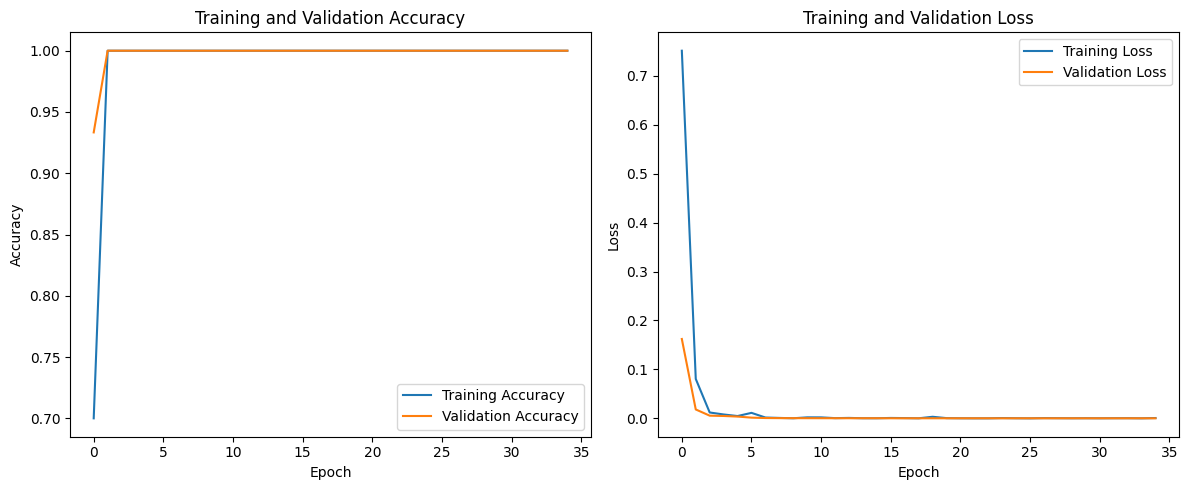

In [23]:
acc = history1.history["accuracy"] + history2.history["accuracy"]
val_acc = history1.history["val_accuracy"] + history2.history["val_accuracy"]

loss = history1.history["loss"] + history2.history["loss"]
val_loss = history1.history["val_loss"] + history2.history["val_loss"]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.plot(acc, label="Training Accuracy")
plt.plot(val_acc, label="Validation Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)

plt.plot(loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [24]:
test_loss, test_accuracy = model.evaluate(
    test_ds,
    verbose=1
)

print("\n========== HASIL TEST ==========")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 1.0000 - loss: 1.0194e-04

========== HASIL TEST ==========
Test Loss     : 0.0001
Test Accuracy : 1.0000
Test Accuracy : 100.00%


In [25]:
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in test_ds:

    predictions = model.predict(
        images,
        verbose=0
    )

    predictions = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(labels.numpy())
    y_pred.extend(predictions)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

              precision    recall  f1-score   support

       botol     1.0000    1.0000    1.0000         8
         box     1.0000    1.0000    1.0000         7

    accuracy                         1.0000        15
   macro avg     1.0000    1.0000    1.0000        15
weighted avg     1.0000    1.0000    1.0000        15



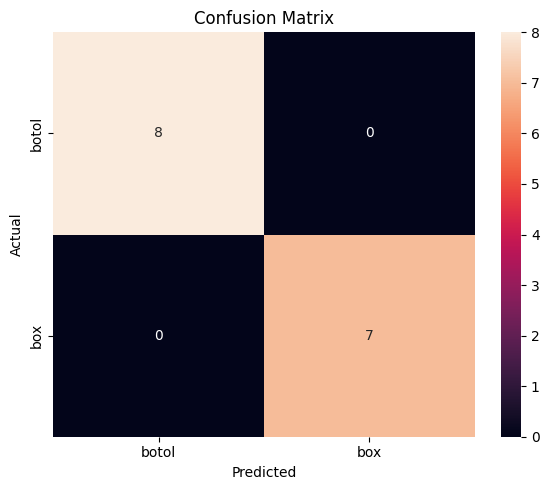

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

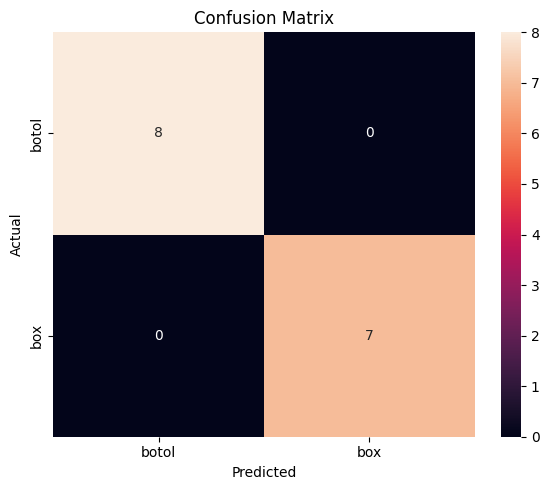

In [27]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "/content/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [28]:
import os
import json

RESULT_DIR = "/content/results"

os.makedirs(
    RESULT_DIR,
    exist_ok=True
)

In [29]:
model_path = os.path.join(
    RESULT_DIR,
    "mobilenetv3_large_botol_box.keras"
)

model.save(model_path)

print("Model berhasil disimpan:")
print(model_path)

Model berhasil disimpan:
/content/results/mobilenetv3_large_botol_box.keras


In [30]:
with open(
    os.path.join(
        RESULT_DIR,
        "class_names.json"
    ),
    "w"
) as f:
    json.dump(
        class_names,
        f,
        indent=4
    )

print("Class names berhasil disimpan.")

Class names berhasil disimpan.


In [31]:
import pandas as pd

history_df = pd.DataFrame({
    "accuracy": acc,
    "val_accuracy": val_acc,
    "loss": loss,
    "val_loss": val_loss
})

history_df.to_csv(
    os.path.join(
        RESULT_DIR,
        "training_history.csv"
    ),
    index=False
)

print("Training history berhasil disimpan.")

Training history berhasil disimpan.


In [32]:
readme_text = f"""# MobileNetV3-Large Transfer Learning

## Image Classification: Botol vs Box

Proyek ini merupakan implementasi metode **Transfer Learning** menggunakan **MobileNetV3-Large** untuk melakukan klasifikasi gambar menjadi dua kelas, yaitu botol dan box.

## Dataset

Dataset terdiri dari:

- Botol: 50 gambar
- Box: 50 gambar
- Total: 100 gambar

Dataset dibagi menjadi:

- 70% training
- 15% validation
- 15% testing

## Model

Model yang digunakan adalah:

**MobileNetV3-Large pretrained on ImageNet**

Tahapan model:

1. MobileNetV3-Large digunakan sebagai pretrained feature extractor.
2. Backbone dibekukan pada tahap training awal.
3. Ditambahkan Global Average Pooling.
4. Ditambahkan Dense layer 128 neuron.
5. Dropout digunakan untuk mengurangi overfitting.
6. Fine-tuning dilakukan pada sebagian layer akhir MobileNetV3-Large.
7. Output akhir terdiri dari 2 kelas: botol dan box.

## Training

Training dilakukan menggunakan Google Colab dengan GPU.

Optimizer:

**Adam**

Learning rate awal:

**0.001**

Learning rate fine-tuning:

**0.00001**

Image size:

**224 x 224 pixels**

## Hasil

Test Accuracy:

**{test_accuracy * 100:.2f}%**

Hasil evaluasi lainnya dapat dilihat pada:

- Classification Report
- Confusion Matrix
- Training History

## Files

- `MobileNetV3_Large_Transfer_Learning.ipynb` — notebook Google Colab
- `mobilenetv3_large_botol_box.keras` — model hasil training
- `class_names.json` — nama kelas
- `training_history.csv` — data training
- `confusion_matrix.png` — confusion matrix

## Tools

- Python
- TensorFlow / Keras
- MobileNetV3-Large
- Scikit-learn
- Google Colab
- GitHub
"""

with open(
    "/content/README.md",
    "w",
    encoding="utf-8"
) as f:
    f.write(readme_text)

print(readme_text)

# MobileNetV3-Large Transfer Learning

## Image Classification: Botol vs Box

Proyek ini merupakan implementasi metode **Transfer Learning** menggunakan **MobileNetV3-Large** untuk melakukan klasifikasi gambar menjadi dua kelas, yaitu botol dan box.

## Dataset

Dataset terdiri dari:

- Botol: 50 gambar
- Box: 50 gambar
- Total: 100 gambar

Dataset dibagi menjadi:

- 70% training
- 15% validation
- 15% testing

## Model

Model yang digunakan adalah:

**MobileNetV3-Large pretrained on ImageNet**

Tahapan model:

1. MobileNetV3-Large digunakan sebagai pretrained feature extractor.
2. Backbone dibekukan pada tahap training awal.
3. Ditambahkan Global Average Pooling.
4. Ditambahkan Dense layer 128 neuron.
5. Dropout digunakan untuk mengurangi overfitting.
6. Fine-tuning dilakukan pada sebagian layer akhir MobileNetV3-Large.
7. Output akhir terdiri dari 2 kelas: botol dan box.

## Training

Training dilakukan menggunakan Google Colab dengan GPU.

Optimizer:

**Adam**

Learning rate awal:



In [33]:
import shutil

shutil.make_archive(
    "/content/MobileNetV3_Large_Project_Results",
    "zip",
    RESULT_DIR
)

print("ZIP hasil berhasil dibuat.")

ZIP hasil berhasil dibuat.


In [35]:
from google.colab import files

files.download(
    "/content/MobileNetV3_Large_Project_Results.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [36]:
import os

print("Isi /content:")
print(os.listdir("/content"))

Isi /content:
['.config', 'README.md', 'dataset', 'MobileNetV3_Large_Project_Results.zip', 'dataset_raw(2).zip', 'confusion_matrix.png', 'results', 'sample_data']


In [37]:
import os

for root, dirs, files in os.walk("/content"):
    level = root.replace("/content", "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    for file in files[:10]:
        print(f"{indent}  {file}")

content/
  README.md
  MobileNetV3_Large_Project_Results.zip
  dataset_raw(2).zip
  confusion_matrix.png
  .config/
    .last_update_check.json
    default_configs.db
    .last_survey_prompt.yaml
    config_sentinel
    gce
    hidden_gcloud_config_universe_descriptor_data_cache_configs.db
    .last_opt_in_prompt.yaml
    active_config
    logs/
      2026.09.30/
        13.27.52.707874.log
        13.28.20.944029.log
        13.28.06.747575.log
        13.28.09.380692.log
        13.28.20.222644.log
        13.27.22.328650.log
    configurations/
      config_default
  dataset/
    dataset_raw/
      box/
        cardboard51.jpg
        cardboard369.jpg
        cardboard21.jpg
        cardboard294.jpg
        cardboard223.jpg
        cardboard56.jpg
        cardboard291.jpg
        cardboard334.jpg
        cardboard69.jpg
        cardboard33.jpg
      botol/
        0218101349.jpg
        0218091144.jpg
        0218100834.jpg
        0218091924.jpg
        0218091807.jpg
        02181

In [39]:
import os

dataset_path = "/content/dataset/dataset_raw"

for kelas in sorted(os.listdir(dataset_path)):
    folder = os.path.join(dataset_path, kelas)

    if os.path.isdir(folder):
        jumlah = len([
            f for f in os.listdir(folder)
            if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
        ])
        print(f"{kelas}: {jumlah} gambar")

botol: 50 gambar
box: 50 gambar


In [40]:
import os
import pandas as pd

dataset_path = "/content/dataset/dataset_raw"
metadata = []

for kelas in sorted(os.listdir(dataset_path)):
    folder = os.path.join(dataset_path, kelas)

    if not os.path.isdir(folder):
        continue

    for filename in sorted(os.listdir(folder)):
        if filename.lower().endswith((".jpg", ".jpeg", ".png", ".webp")):
            filepath = os.path.join(folder, filename)

            metadata.append({
                "filename": filename,
                "class": kelas,
                "filepath": filepath
            })

metadata_df = pd.DataFrame(metadata)

# Simpan metadata
metadata_path = "/content/metadata.csv"
metadata_df.to_csv(metadata_path, index=False)

print("Metadata berhasil dibuat!")
print(f"Jumlah total gambar: {len(metadata_df)}")
print("\nJumlah per kelas:")
print(metadata_df["class"].value_counts())
print("\n5 data pertama:")
display(metadata_df.head())

Metadata berhasil dibuat!
Jumlah total gambar: 100

Jumlah per kelas:
class
botol    50
box      50
Name: count, dtype: int64

5 data pertama:


,filename,class,filepath
0,0218091108.jpg,botol,/content/dataset/dataset_raw/botol/0218091108.jpg
1,0218091144.jpg,botol,/content/dataset/dataset_raw/botol/0218091144.jpg
2,0218091233.jpg,botol,/content/dataset/dataset_raw/botol/0218091233.jpg
3,0218091249.jpg,botol,/content/dataset/dataset_raw/botol/0218091249.jpg
4,0218091318.jpg,botol,/content/dataset/dataset_raw/botol/0218091318.jpg


In [41]:
import pandas as pd

history_path = "/content/results/training_history.csv"

history = pd.read_csv(history_path)

print("Kolom yang tersedia:")
print(history.columns.tolist())

print("\nJumlah epoch:")
print(len(history))

display(history.head())

Kolom yang tersedia:
['accuracy', 'val_accuracy', 'loss', 'val_loss']

Jumlah epoch:
35


,accuracy,val_accuracy,loss,val_loss
0,0.7,0.933333,0.751115,0.162238
1,1.0,1.000000,0.080611,0.018269
2,1.0,1.000000,0.012079,0.005584
3,1.0,1.000000,0.008031,0.004949
4,1.0,1.000000,0.004818,0.003749


In [42]:
print("\nHasil akhir training:")

for col in history.columns:
    print(f"{col}: {history[col].iloc[-1]}")


Hasil akhir training:
accuracy: 1.0
val_accuracy: 1.0
loss: 0.0007598844822496
val_loss: 0.0002301230560988


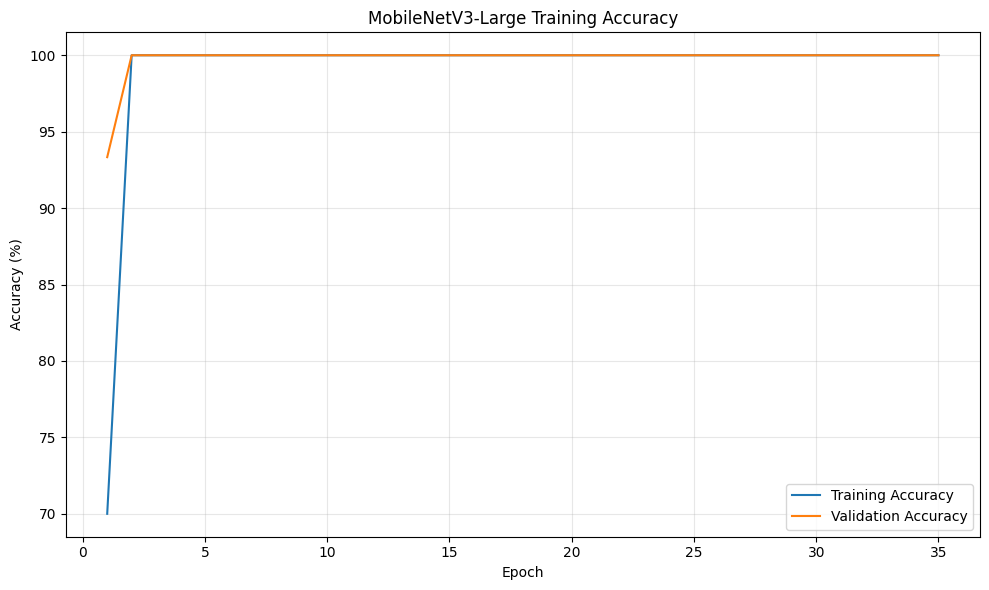

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

history = pd.read_csv("/content/results/training_history.csv")

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(history) + 1),
    history["accuracy"] * 100,
    label="Training Accuracy"
)

plt.plot(
    range(1, len(history) + 1),
    history["val_accuracy"] * 100,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("MobileNetV3-Large Training Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "/content/results/accuracy_per_epoch.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

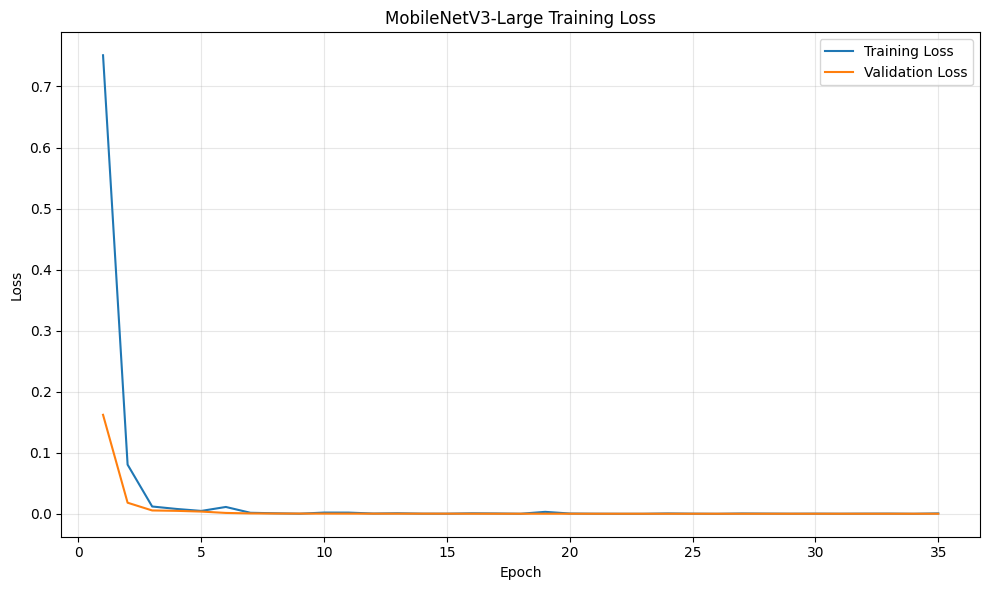

In [44]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(history) + 1),
    history["loss"],
    label="Training Loss"
)

plt.plot(
    range(1, len(history) + 1),
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobileNetV3-Large Training Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "/content/results/loss_per_epoch.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [45]:
import tensorflow as tf
import numpy as np
import time

model = tf.keras.models.load_model(
    "/content/results/mobilenetv3_large_botol_box.keras"
)

# Ambil 1 batch dari test dataset
images, labels = next(iter(test_ds))

# Warm-up
for _ in range(10):
    _ = model(images, training=False)

# Pengukuran
times = []

for _ in range(50):
    start = time.perf_counter()

    _ = model(images, training=False)

    end = time.perf_counter()

    times.append(end - start)

avg_batch_latency = np.mean(times)
avg_image_latency = avg_batch_latency / images.shape[0]

print("========== LATENCY ==========")
print(f"Batch size              : {images.shape[0]}")
print(f"Average batch latency   : {avg_batch_latency * 1000:.2f} ms")
print(f"Average image latency   : {avg_image_latency * 1000:.2f} ms")
print(f"FPS                     : {1 / avg_image_latency:.2f}")

========== LATENCY ==========
Batch size              : 15
Average batch latency   : 294.73 ms
Average image latency   : 19.65 ms
FPS                     : 50.89


In [48]:
test_loss, test_accuracy = model.evaluate(
    test_ds,
    verbose=0
)

latency_ms = avg_image_latency * 1000
fps = 1 / avg_image_latency

evaluation_text = f"""
========================================
MOBILENETV3-LARGE EVALUATION
========================================

Dataset:
- Botol: 50 images
- Box: 50 images
- Total: 100 images

Training:
- Epoch: {len(history)}
- Final Training Accuracy: {history['accuracy'].iloc[-1] * 100:.2f}%
- Final Validation Accuracy: {history['val_accuracy'].iloc[-1] * 100:.2f}%

Test:
- Test Accuracy: {test_accuracy * 100:.2f}%
- Test Loss: {test_loss:.6f}

Latency:
- Batch Size: {images.shape[0]}
- Average Image Latency: {latency_ms:.2f} ms
- Estimated FPS: {fps:.2f}

Catatan:
Dataset relatif kecil, yaitu 50 citra per kelas.
Accuracy yang tinggi perlu diinterpretasikan dengan hati-hati
dan belum tentu menunjukkan generalisasi pada dataset yang lebih besar.
"""

with open(
    "/content/results/evaluation_results.txt",
    "w",
    encoding="utf-8"
) as f:
    f.write(evaluation_text)

print(evaluation_text)


MOBILENETV3-LARGE EVALUATION

Dataset:
- Botol: 50 images
- Box: 50 images
- Total: 100 images

Training:
- Epoch: 35
- Final Training Accuracy: 100.00%
- Final Validation Accuracy: 100.00%

Test:
- Test Accuracy: 100.00%
- Test Loss: 0.000102

Latency:
- Batch Size: 15
- Average Image Latency: 19.65 ms
- Estimated FPS: 50.89

Catatan:
Dataset relatif kecil, yaitu 50 citra per kelas.
Accuracy yang tinggi perlu diinterpretasikan dengan hati-hati
dan belum tentu menunjukkan generalisasi pada dataset yang lebih besar.



In [47]:
import pandas as pd
import os

metadata_df = pd.read_csv("/content/metadata.csv")

metadata_df["width"] = 200
metadata_df["height"] = 150
metadata_df["format"] = metadata_df["filename"].apply(
    lambda x: os.path.splitext(x)[1].replace(".", "").upper()
)

metadata_df.to_csv(
    "/content/metadata.csv",
    index=False
)

print("metadata.csv diperbarui.")
display(metadata_df.head())

metadata.csv diperbarui.


,filename,class,filepath,width,height,format
0,0218091108.jpg,botol,/content/dataset/dataset_raw/botol/0218091108.jpg,200,150,JPG
1,0218091144.jpg,botol,/content/dataset/dataset_raw/botol/0218091144.jpg,200,150,JPG
2,0218091233.jpg,botol,/content/dataset/dataset_raw/botol/0218091233.jpg,200,150,JPG
3,0218091249.jpg,botol,/content/dataset/dataset_raw/botol/0218091249.jpg,200,150,JPG
4,0218091318.jpg,botol,/content/dataset/dataset_raw/botol/0218091318.jpg,200,150,JPG


In [49]:
import pandas as pd

history = pd.read_csv("/content/results/training_history.csv")

print("Jumlah epoch:", len(history))
print("\nHasil epoch terakhir:")
display(history.tail(1))

Jumlah epoch: 35

Hasil epoch terakhir:


,accuracy,val_accuracy,loss,val_loss
34,1.0,1.0,0.00076,0.00023


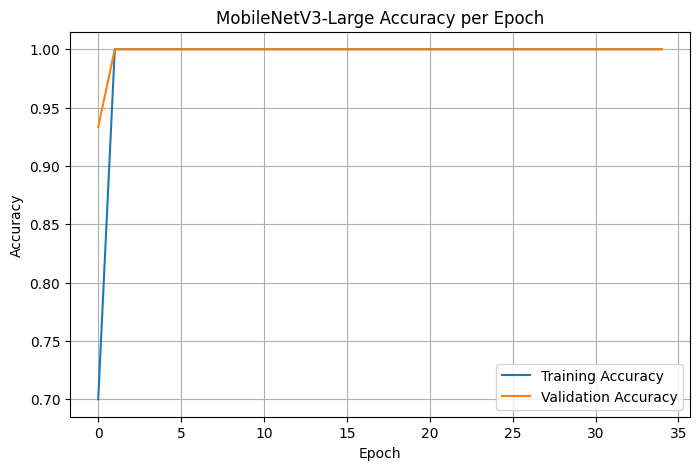

In [50]:
import pandas as pd
import matplotlib.pyplot as plt

history = pd.read_csv("/content/results/training_history.csv")

plt.figure(figsize=(8,5))
plt.plot(history["accuracy"], label="Training Accuracy")
plt.plot(history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV3-Large Accuracy per Epoch")
plt.legend()
plt.grid(True)

plt.savefig("/content/results/accuracy_per_epoch.png", dpi=300, bbox_inches="tight")
plt.show()

In [51]:
import tensorflow as tf
import time
import numpy as np

model = tf.keras.models.load_model(
    "/content/results/mobilenetv3_large_botol_box.keras"
)

# Dummy input sesuai input model
input_shape = model.input_shape
print("Input model:", input_shape)

dummy_input = tf.random.uniform(
    [1, input_shape[1], input_shape[2], input_shape[3]]
)

# Warm-up
for _ in range(10):
    _ = model(dummy_input, training=False)

# Pengukuran
n_runs = 50
times = []

for _ in range(n_runs):
    start = time.perf_counter()
    _ = model(dummy_input, training=False)
    end = time.perf_counter()
    times.append((end - start) * 1000)

latency_mean = np.mean(times)
latency_std = np.std(times)

print(f"Latency rata-rata : {latency_mean:.2f} ms/image")
print(f"Standar deviasi   : {latency_std:.2f} ms")

Input model: (None, 224, 224, 3)
Latency rata-rata : 205.20 ms/image
Standar deviasi   : 30.18 ms


In [52]:
# ============================================================
# PART 1 — PERSIAPAN DATASET UNTUK E2 & E3
# ============================================================

import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf

from pathlib import Path
from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# 1. KONFIGURASI
# ------------------------------------------------------------

SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 35

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATA_DIR = Path("/content/dataset/dataset_raw")
RESULT_DIR = Path("/content/results_3_experiments")
RESULT_DIR.mkdir(parents=True, exist_ok=True)

CLASSES = ["botol", "box"]

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))
print()

# ------------------------------------------------------------
# 2. CEK DATASET
# ------------------------------------------------------------

image_paths = []
labels = []

valid_ext = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

for class_idx, class_name in enumerate(CLASSES):

    class_dir = DATA_DIR / class_name

    files = [
        p for p in class_dir.iterdir()
        if p.is_file() and p.suffix.lower() in valid_ext
    ]

    print(f"{class_name}: {len(files)} gambar")

    for p in sorted(files):
        image_paths.append(str(p))
        labels.append(class_idx)

image_paths = np.array(image_paths)
labels = np.array(labels)

print()
print("Total gambar:", len(image_paths))

# ------------------------------------------------------------
# 3. SPLIT DATA
#    70% TRAIN
#    15% VALIDATION
#    15% TEST
# ------------------------------------------------------------

X_train, X_temp, y_train, y_temp = train_test_split(
    image_paths,
    labels,
    test_size=0.30,
    stratify=labels,
    random_state=SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=SEED
)

print()
print("=== HASIL SPLIT ===")
print("Train      :", len(X_train))
print("Validation :", len(X_val))
print("Test       :", len(X_test))

# ------------------------------------------------------------
# 4. CEK DISTRIBUSI KELAS
# ------------------------------------------------------------

def show_distribution(name, y):
    counts = pd.Series(y).map({
        0: "botol",
        1: "box"
    }).value_counts()

    print(f"\n{name}:")
    print(counts)

show_distribution("TRAIN", y_train)
show_distribution("VALIDATION", y_val)
show_distribution("TEST", y_test)

# ------------------------------------------------------------
# 5. SIMPAN SPLIT
# ------------------------------------------------------------

split_df = pd.DataFrame({
    "filepath": np.concatenate([X_train, X_val, X_test]),
    "class": np.concatenate([
        [CLASSES[i] for i in y_train],
        [CLASSES[i] for i in y_val],
        [CLASSES[i] for i in y_test]
    ]),
    "split": (
        ["train"] * len(X_train) +
        ["validation"] * len(X_val) +
        ["test"] * len(X_test)
    )
})

split_df.to_csv(
    RESULT_DIR / "data_split.csv",
    index=False
)

print()
print("Split disimpan di:")
print(RESULT_DIR / "data_split.csv")

# ------------------------------------------------------------
# 6. DATA PIPELINE
# ------------------------------------------------------------

AUTOTUNE = tf.data.AUTOTUNE

def load_image(path, label):

    image = tf.io.read_file(path)

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    image = tf.cast(
        image,
        tf.float32
    )

    return image, tf.cast(label, tf.float32)


def make_dataset(paths, labels, training=False):

    ds = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    if training:
        ds = ds.shuffle(
            buffer_size=len(paths),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    ds = ds.map(
        load_image,
        num_parallel_calls=AUTOTUNE
    )

    ds = ds.batch(BATCH_SIZE)

    ds = ds.prefetch(AUTOTUNE)

    return ds


train_ds = make_dataset(
    X_train,
    y_train,
    training=True
)

val_ds = make_dataset(
    X_val,
    y_val,
    training=False
)

test_ds = make_dataset(
    X_test,
    y_test,
    training=False
)

print()
print("Dataset pipeline siap.")
print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Val batches  :", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches :", tf.data.experimental.cardinality(test_ds).numpy())

print()
print("=" * 55)
print("PART 1 SELESAI ✅")
print("=" * 55)

TensorFlow: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

botol: 50 gambar
box: 50 gambar

Total gambar: 100

=== HASIL SPLIT ===
Train      : 70
Validation : 15
Test       : 15

TRAIN:
box      35
botol    35
Name: count, dtype: int64

VALIDATION:
box      8
botol    7
Name: count, dtype: int64

TEST:
botol    8
box      7
Name: count, dtype: int64

Split disimpan di:
/content/results_3_experiments/data_split.csv

Dataset pipeline siap.
Train batches: 5
Val batches  : 1
Test batches : 1

PART 1 SELESAI ✅


In [53]:
# ============================================================
# PART 2 — E2 SCRATCH
# MobileNetV3-Large tanpa pretrained weights
# ============================================================

import tensorflow as tf
import pandas as pd
from pathlib import Path

# ------------------------------------------------------------
# 1. RESET SESSION + SEED
# ------------------------------------------------------------

tf.keras.backend.clear_session()

SEED = 42
tf.random.set_seed(SEED)

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 35

RESULT_DIR = Path("/content/results_3_experiments")
RESULT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 2. BUAT MODEL MOBILE-NETV3 LARGE
# ------------------------------------------------------------

base_model = tf.keras.applications.MobileNetV3Large(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    weights=None,          # <-- SCRATCH
    include_preprocessing=True
)

# Semua layer dilatih
base_model.trainable = True

inputs = tf.keras.Input(
    shape=(*IMG_SIZE, 3)
)

x = base_model(
    inputs,
    training=True
)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dropout(0.2)(x)

outputs = tf.keras.layers.Dense(
    1,
    activation="sigmoid"
)(x)

model_e2 = tf.keras.Model(
    inputs,
    outputs,
    name="MobileNetV3Large_E2_Scratch"
)

# ------------------------------------------------------------
# 3. COMPILE
# ------------------------------------------------------------

model_e2.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("=" * 60)
print("MODEL E2 — SCRATCH")
print("=" * 60)

print("Weights      : None / Random")
print("Input        :", IMG_SIZE)
print("Batch size   :", BATCH_SIZE)
print("Epoch        :", EPOCHS)
print("Learning rate: 1e-3")
print()

# ------------------------------------------------------------
# 4. CALLBACK
# ------------------------------------------------------------

checkpoint_e2 = tf.keras.callbacks.ModelCheckpoint(
    filepath=str(
        RESULT_DIR / "E2_scratch_best.keras"
    ),
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

csv_logger_e2 = tf.keras.callbacks.CSVLogger(
    str(
        RESULT_DIR / "E2_scratch_history.csv"
    )
)

# ------------------------------------------------------------
# 5. TRAINING
# ------------------------------------------------------------

print("Mulai training E2 Scratch...")
print()

history_e2 = model_e2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[
        checkpoint_e2,
        csv_logger_e2
    ],
    verbose=1
)

# ------------------------------------------------------------
# 6. SIMPAN MODEL TERAKHIR
# ------------------------------------------------------------

model_e2.save(
    RESULT_DIR / "E2_scratch_final.keras"
)

# ------------------------------------------------------------
# 7. HASIL AKHIR TRAINING
# ------------------------------------------------------------

history_df_e2 = pd.DataFrame(
    history_e2.history
)

print()
print("=" * 60)
print("HASIL E2 SCRATCH")
print("=" * 60)

print(
    f"Final Train Accuracy : "
    f"{history_df_e2['accuracy'].iloc[-1]:.4f}"
)

print(
    f"Final Val Accuracy   : "
    f"{history_df_e2['val_accuracy'].iloc[-1]:.4f}"
)

print(
    f"Best Val Accuracy    : "
    f"{history_df_e2['val_accuracy'].max():.4f}"
)

print(
    f"Final Train Loss     : "
    f"{history_df_e2['loss'].iloc[-1]:.6f}"
)

print(
    f"Final Val Loss       : "
    f"{history_df_e2['val_loss'].iloc[-1]:.6f}"
)

print()
print("Model disimpan:")
print(
    RESULT_DIR /
    "E2_scratch_final.keras"
)

print()
print("=" * 60)
print("PART 2 SELESAI ✅")
print("=" * 60)

MODEL E2 — SCRATCH
Weights      : None / Random
Input        : (224, 224)
Batch size   : 16
Epoch        : 35
Learning rate: 1e-3

Mulai training E2 Scratch...

Epoch 1/35
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.6439 - loss: 0.4389 
Epoch 1: val_accuracy improved from None to 0.46667, saving model to /content/results_3_experiments/E2_scratch_best.keras

Epoch 1: finished saving model to /content/results_3_experiments/E2_scratch_best.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 133s 13s/step - accuracy: 0.7714 - loss: 0.3101 - val_accuracy: 0.4667 - val_loss: 0.6933
Epoch 2/35
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 1.0000 - loss: 0.0042
Epoch 2: val_accuracy improved from 0.46667 to 0.53333, saving model to /content/results_3_experiments/E2_scratch_best.keras

Epoch 2: finished saving model to /content/results_3_experiments/E2_scratch_best.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 259ms/step - accuracy: 1.0000 - loss: 0.0038 - val_accuracy: 0.5333 - val_loss: 0.6928
Epoch 3/35
5/5 ━━━━━

In [54]:
# ============================================================
# PART 3 — E3 TUNING
# MobileNetV3-Large + ImageNet pretrained
# Partial fine-tuning
# ============================================================

import tensorflow as tf
import pandas as pd
from pathlib import Path

# ------------------------------------------------------------
# 1. RESET SESSION + SEED
# ------------------------------------------------------------

tf.keras.backend.clear_session()

SEED = 42
tf.random.set_seed(SEED)

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 35

RESULT_DIR = Path("/content/results_3_experiments")
RESULT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 2. LOAD MOBILENETV3-LARGE PRETRAINED
# ------------------------------------------------------------

base_model_e3 = tf.keras.applications.MobileNetV3Large(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    weights="imagenet",
    include_preprocessing=True
)

# ------------------------------------------------------------
# 3. FINE-TUNING
# ------------------------------------------------------------

# Awalnya semua layer dibekukan
base_model_e3.trainable = False

# Buka sebagian layer terakhir
# untuk fine-tuning
FINE_TUNE_LAYERS = 40

for layer in base_model_e3.layers[-FINE_TUNE_LAYERS:]:

    # Batch Normalization tetap dibekukan
    # agar training lebih stabil pada dataset kecil
    if not isinstance(
        layer,
        tf.keras.layers.BatchNormalization
    ):
        layer.trainable = True

# ------------------------------------------------------------
# 4. CLASSIFICATION HEAD
# ------------------------------------------------------------

inputs = tf.keras.Input(
    shape=(*IMG_SIZE, 3)
)

x = base_model_e3(
    inputs,
    training=False
)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dropout(0.2)(x)

outputs = tf.keras.layers.Dense(
    1,
    activation="sigmoid"
)(x)

model_e3 = tf.keras.Model(
    inputs,
    outputs,
    name="MobileNetV3Large_E3_Tuning"
)

# ------------------------------------------------------------
# 5. COMPILE
# ------------------------------------------------------------

model_e3.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# ------------------------------------------------------------
# 6. CEK JUMLAH PARAMETER
# ------------------------------------------------------------

trainable_params = np.sum([
    np.prod(v.shape)
    for v in model_e3.trainable_weights
])

total_params = np.sum([
    np.prod(v.shape)
    for v in model_e3.weights
])

print("=" * 60)
print("MODEL E3 — TUNING")
print("=" * 60)

print("Weights       : ImageNet")
print("Fine-tune     : Last 40 layers")
print("BatchNorm     : Frozen")
print("Input         :", IMG_SIZE)
print("Batch size    :", BATCH_SIZE)
print("Epoch         :", EPOCHS)
print("Learning rate : 1e-4")
print()
print("Trainable parameters :", trainable_params)
print("Total parameters     :", total_params)

# ------------------------------------------------------------
# 7. CALLBACK
# ------------------------------------------------------------

checkpoint_e3 = tf.keras.callbacks.ModelCheckpoint(
    filepath=str(
        RESULT_DIR / "E3_tuning_best.keras"
    ),
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

csv_logger_e3 = tf.keras.callbacks.CSVLogger(
    str(
        RESULT_DIR / "E3_tuning_history.csv"
    )
)

# ------------------------------------------------------------
# 8. TRAINING
# ------------------------------------------------------------

print()
print("Mulai training E3 Tuning...")
print()

history_e3 = model_e3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[
        checkpoint_e3,
        csv_logger_e3
    ],
    verbose=1
)

# ------------------------------------------------------------
# 9. SIMPAN MODEL
# ------------------------------------------------------------

model_e3.save(
    RESULT_DIR / "E3_tuning_final.keras"
)

# ------------------------------------------------------------
# 10. RINGKASAN HASIL
# ------------------------------------------------------------

history_df_e3 = pd.DataFrame(
    history_e3.history
)

print()
print("=" * 60)
print("HASIL E3 TUNING")
print("=" * 60)

print(
    f"Final Train Accuracy : "
    f"{history_df_e3['accuracy'].iloc[-1]:.4f}"
)

print(
    f"Final Val Accuracy   : "
    f"{history_df_e3['val_accuracy'].iloc[-1]:.4f}"
)

print(
    f"Best Val Accuracy    : "
    f"{history_df_e3['val_accuracy'].max():.4f}"
)

print(
    f"Final Train Loss     : "
    f"{history_df_e3['loss'].iloc[-1]:.6f}"
)

print(
    f"Final Val Loss       : "
    f"{history_df_e3['val_loss'].iloc[-1]:.6f}"
)

print()
print("Model disimpan:")
print(
    RESULT_DIR /
    "E3_tuning_final.keras"
)

print()
print("=" * 60)
print("PART 3 SELESAI ✅")
print("=" * 60)

MODEL E3 — TUNING
Weights       : ImageNet
Fine-tune     : Last 40 layers
BatchNorm     : Frozen
Input         : (224, 224)
Batch size    : 16
Epoch         : 35
Learning rate : 1e-4

Trainable parameters : 2075113
Total parameters     : 2997313

Mulai training E3 Tuning...

Epoch 1/35
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6978 - loss: 0.5848  
Epoch 1: val_accuracy improved from None to 1.00000, saving model to /content/results_3_experiments/E3_tuning_best.keras

Epoch 1: finished saving model to /content/results_3_experiments/E3_tuning_best.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step - accuracy: 0.7857 - loss: 0.4910 - val_accuracy: 1.0000 - val_loss: 0.2330
Epoch 2/35
3/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 1.0000 - loss: 0.1520 
Epoch 2: val_accuracy did not improve from 1.00000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 1.0000 - loss: 0.1090 - val_accuracy: 1.0000 - val_loss: 0.0993
Epoch 3/35
3/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 1.0000 - l

Semua model berhasil dimuat.

E1_Pretrained
Output shape: (None, 2)

E2_Scratch
Output shape: (None, 1)

E3_Tuning
Output shape: (None, 1)


E1_Pretrained
Jumlah y_true : 15
Jumlah y_pred : 15

Test Accuracy : 1.0000
Latency       : 206.36 ms/image
Latency Std   : 31.76 ms

Classification Report:
              precision    recall  f1-score   support

       botol     1.0000    1.0000    1.0000         8
         box     1.0000    1.0000    1.0000         7

    accuracy                         1.0000        15
   macro avg     1.0000    1.0000    1.0000        15
weighted avg     1.0000    1.0000    1.0000        15


E2_Scratch


Jumlah y_true : 15
Jumlah y_pred : 15

Test Accuracy : 0.4667
Latency       : 181.46 ms/image
Latency Std   : 6.65 ms

Classification Report:
              precision    recall  f1-score   support

       botol     0.0000    0.0000    0.0000         8
         box     0.4667    1.0000    0.6364         7

    accuracy                         0.4667        15
   macro avg     0.2333    0.5000    0.3182        15
weighted avg     0.2178    0.4667    0.2970        15


E3_Tuning


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Jumlah y_true : 15
Jumlah y_pred : 15

Test Accuracy : 1.0000
Latency       : 198.76 ms/image
Latency Std   : 29.70 ms

Classification Report:
              precision    recall  f1-score   support

       botol     1.0000    1.0000    1.0000         8
         box     1.0000    1.0000    1.0000         7

    accuracy                         1.0000        15
   macro avg     1.0000    1.0000    1.0000        15
weighted avg     1.0000    1.0000    1.0000        15


HASIL EVALUASI 3 MODEL


,Experiment,Test Accuracy,Latency (ms/image),Latency Std (ms)
0,E1_Pretrained,1.000000,206.363829,31.755173
1,E2_Scratch,0.466667,181.461339,6.652783
2,E3_Tuning,1.000000,198.755250,29.697098


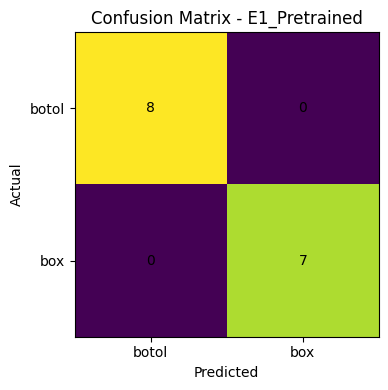

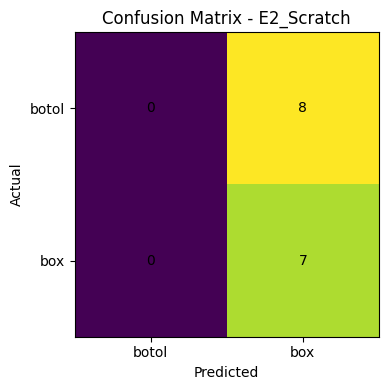

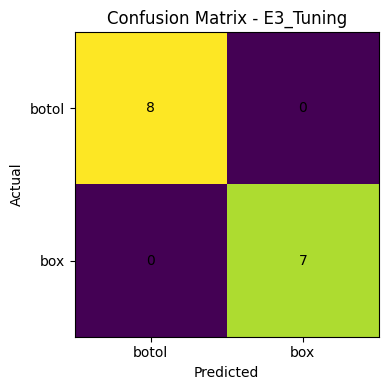


PART 4 SELESAI ✅


In [57]:
# ============================================================
# PART 4 FIX FINAL
# Evaluasi E1, E2, E3
# Menangani output E1 = 2 kelas dan E2/E3 = 1 output
# ============================================================

import os
import time
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

RESULT_DIR = Path("/content/results_3_experiments")
RESULT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 1. LOAD MODEL
# ------------------------------------------------------------

E1_PATH = "/content/results/mobilenetv3_large_botol_box.keras"
E2_PATH = RESULT_DIR / "E2_scratch_final.keras"
E3_PATH = RESULT_DIR / "E3_tuning_final.keras"

model_e1 = tf.keras.models.load_model(E1_PATH)
model_e2 = tf.keras.models.load_model(E2_PATH)
model_e3 = tf.keras.models.load_model(E3_PATH)

models = {
    "E1_Pretrained": model_e1,
    "E2_Scratch": model_e2,
    "E3_Tuning": model_e3
}

print("Semua model berhasil dimuat.")
print()

for name, model in models.items():
    print(name)
    print("Output shape:", model.output_shape)
    print()


# ------------------------------------------------------------
# 2. FUNGSI EVALUASI
# ------------------------------------------------------------

def evaluate_model(model, test_ds):

    y_true = []
    y_pred = []

    for images, labels in test_ds:

        predictions = model.predict(
            images,
            verbose=0
        )

        predictions = np.asarray(predictions)
        labels = np.asarray(labels).reshape(-1)

        # ----------------------------------------------------
        # Jika output model = (batch, 2)
        # Contoh:
        # [[0.1, 0.9],
        #  [0.8, 0.2]]
        #
        # gunakan argmax
        # ----------------------------------------------------

        if predictions.ndim == 2 and predictions.shape[1] == 2:

            batch_pred = np.argmax(
                predictions,
                axis=1
            )

        # ----------------------------------------------------
        # Jika output model = (batch, 1)
        # gunakan threshold 0.5
        # ----------------------------------------------------

        else:

            predictions = predictions.reshape(-1)

            batch_pred = (
                predictions >= 0.5
            ).astype(int)

        y_true.extend(
            labels.astype(int).tolist()
        )

        y_pred.extend(
            batch_pred.astype(int).tolist()
        )

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    print("Jumlah y_true :", len(y_true))
    print("Jumlah y_pred :", len(y_pred))

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    return (
        accuracy,
        y_true,
        y_pred,
        cm
    )


# ------------------------------------------------------------
# 3. FUNGSI LATENCY
# ------------------------------------------------------------

def measure_latency(model, test_ds):

    images, _ = next(iter(test_ds))

    image = images[:1]

    # Warm-up
    for _ in range(10):
        output = model(
            image,
            training=False
        )

    _ = tf.reduce_sum(output).numpy()

    times = []

    for _ in range(50):

        start = time.perf_counter()

        output = model(
            image,
            training=False
        )

        _ = tf.reduce_sum(output).numpy()

        end = time.perf_counter()

        times.append(
            (end - start) * 1000
        )

    return (
        np.mean(times),
        np.std(times)
    )


# ------------------------------------------------------------
# 4. EVALUASI SEMUA MODEL
# ------------------------------------------------------------

results = []
prediction_store = {}

for model_name, model in models.items():

    print()
    print("=" * 60)
    print(model_name)
    print("=" * 60)

    accuracy, y_true, y_pred, cm = evaluate_model(
        model,
        test_ds
    )

    latency_mean, latency_std = measure_latency(
        model,
        test_ds
    )

    print()
    print(
        f"Test Accuracy : {accuracy:.4f}"
    )

    print(
        f"Latency       : "
        f"{latency_mean:.2f} ms/image"
    )

    print(
        f"Latency Std   : "
        f"{latency_std:.2f} ms"
    )

    print()
    print("Classification Report:")

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=["botol", "box"],
            digits=4
        )
    )

    results.append({
        "Experiment": model_name,
        "Test Accuracy": accuracy,
        "Latency (ms/image)": latency_mean,
        "Latency Std (ms)": latency_std
    })

    prediction_store[model_name] = {
        "y_true": y_true,
        "y_pred": y_pred,
        "cm": cm
    }


# ------------------------------------------------------------
# 5. TABEL HASIL
# ------------------------------------------------------------

results_df = pd.DataFrame(results)

results_df.to_csv(
    RESULT_DIR / "hasil_evaluasi_3_model.csv",
    index=False
)

print()
print("=" * 60)
print("HASIL EVALUASI 3 MODEL")
print("=" * 60)

display(results_df)


# ------------------------------------------------------------
# 6. CONFUSION MATRIX
# ------------------------------------------------------------

for model_name, data in prediction_store.items():

    cm = data["cm"]

    plt.figure(figsize=(5, 4))

    plt.imshow(cm)

    plt.title(
        f"Confusion Matrix - {model_name}"
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.xticks(
        [0, 1],
        ["botol", "box"]
    )

    plt.yticks(
        [0, 1],
        ["botol", "box"]
    )

    for i in range(2):
        for j in range(2):

            plt.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center"
            )

    plt.tight_layout()

    filename = (
        model_name.lower()
        + "_confusion_matrix.png"
    )

    plt.savefig(
        RESULT_DIR / filename,
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()


# ------------------------------------------------------------
# 7. SIMPAN TXT
# ------------------------------------------------------------

with open(
    RESULT_DIR / "hasil_evaluasi.txt",
    "w"
) as f:

    f.write(
        "HASIL EVALUASI 3 MODEL MOBILENETV3-LARGE\n"
    )

    f.write("=" * 55 + "\n\n")

    for _, row in results_df.iterrows():

        f.write(
            f"{row['Experiment']}\n"
        )

        f.write(
            f"Test Accuracy : "
            f"{row['Test Accuracy']:.4f}\n"
        )

        f.write(
            f"Latency       : "
            f"{row['Latency (ms/image)']:.2f} ms/image\n"
        )

        f.write(
            f"Latency Std   : "
            f"{row['Latency Std (ms)']:.2f} ms\n\n"
        )

print()
print("=" * 60)
print("PART 4 SELESAI ✅")
print("=" * 60)

E1 columns:
['accuracy', 'val_accuracy', 'loss', 'val_loss']

E2 columns:
['epoch', 'accuracy', 'loss', 'val_accuracy', 'val_loss']

E3 columns:
['epoch', 'accuracy', 'loss', 'val_accuracy', 'val_loss']

TABEL 3 EKSPERIMEN


,Experiment,Test Accuracy,Best Val Accuracy,Final Val Accuracy,Latency (ms/image),Latency Std (ms)
0,E1_Pretrained,1.0000,1.0000,1.0000,206.36,31.76
1,E2_Scratch,0.4667,0.5333,0.5333,181.46,6.65
2,E3_Tuning,1.0000,1.0000,1.0000,198.76,29.70


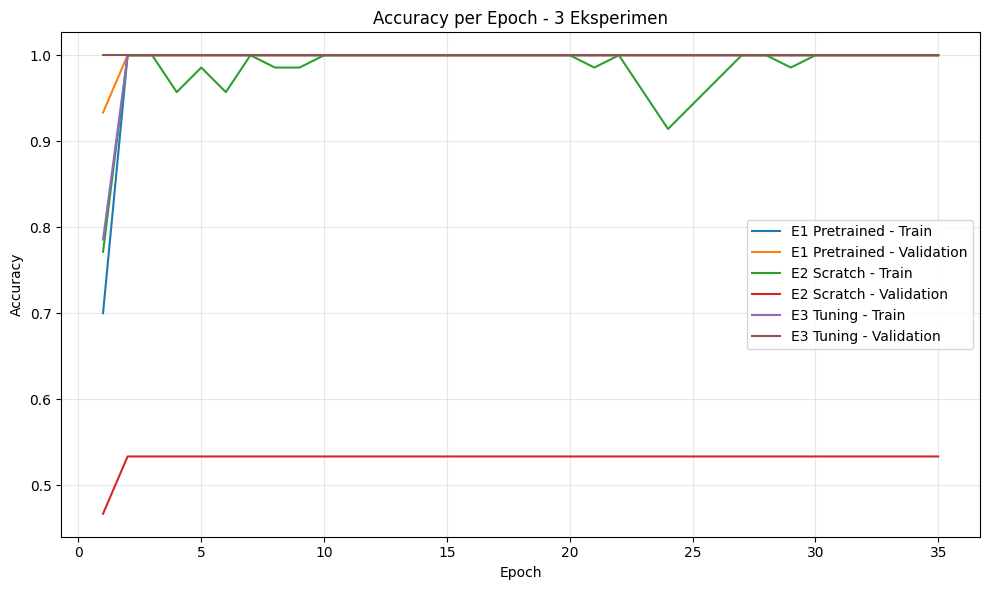

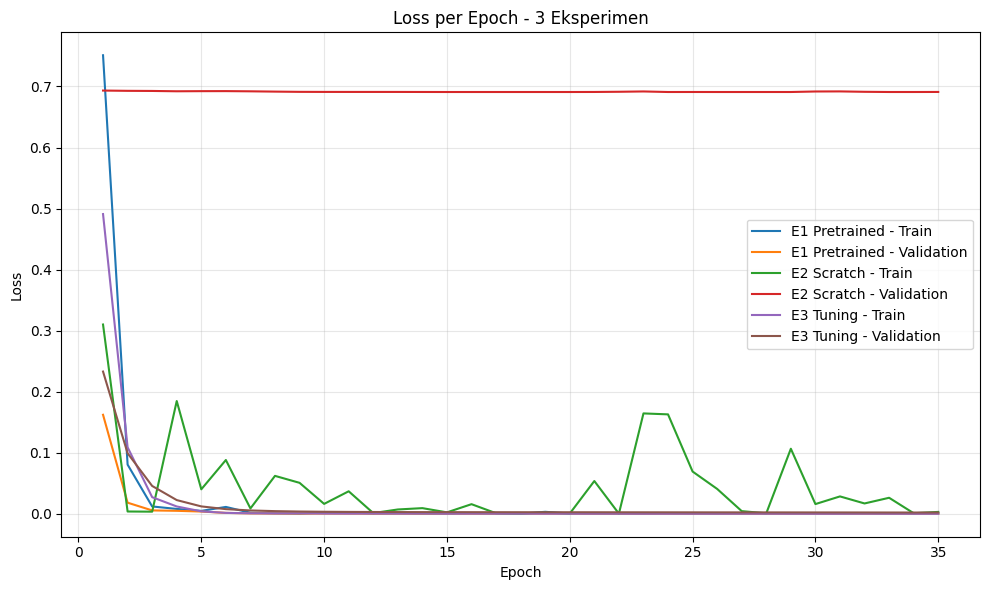


PART 5 SELESAI ✅


In [58]:
# ============================================================
# PART 5 — TABEL 3 EKSPERIMEN + GRAFIK
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RESULT_DIR = Path("/content/results_3_experiments")

# ------------------------------------------------------------
# 1. LOAD HISTORY E2 DAN E3
# ------------------------------------------------------------

e2_history = pd.read_csv(
    RESULT_DIR / "E2_scratch_history.csv"
)

e3_history = pd.read_csv(
    RESULT_DIR / "E3_tuning_history.csv"
)

# ------------------------------------------------------------
# 2. LOAD HISTORY E1
# ------------------------------------------------------------

e1_history_path = Path(
    "/content/results/training_history.csv"
)

e1_history = pd.read_csv(
    e1_history_path
)

print("E1 columns:")
print(e1_history.columns.tolist())

print()
print("E2 columns:")
print(e2_history.columns.tolist())

print()
print("E3 columns:")
print(e3_history.columns.tolist())


# ------------------------------------------------------------
# 3. TABEL HASIL AKHIR 3 EKSPERIMEN
# ------------------------------------------------------------

eval_df = pd.read_csv(
    RESULT_DIR / "hasil_evaluasi_3_model.csv"
)

# Ambil best validation accuracy
best_val = {
    "E1_Pretrained": e1_history["val_accuracy"].max(),
    "E2_Scratch": e2_history["val_accuracy"].max(),
    "E3_Tuning": e3_history["val_accuracy"].max()
}

# Ambil final validation accuracy
final_val = {
    "E1_Pretrained": e1_history["val_accuracy"].iloc[-1],
    "E2_Scratch": e2_history["val_accuracy"].iloc[-1],
    "E3_Tuning": e3_history["val_accuracy"].iloc[-1]
}

# Buat tabel
final_table = eval_df.copy()

final_table["Best Val Accuracy"] = (
    final_table["Experiment"]
    .map(best_val)
)

final_table["Final Val Accuracy"] = (
    final_table["Experiment"]
    .map(final_val)
)

final_table = final_table[
    [
        "Experiment",
        "Test Accuracy",
        "Best Val Accuracy",
        "Final Val Accuracy",
        "Latency (ms/image)",
        "Latency Std (ms)"
    ]
]

# ------------------------------------------------------------
# 4. PEMBULATAN
# ------------------------------------------------------------

for col in [
    "Test Accuracy",
    "Best Val Accuracy",
    "Final Val Accuracy"
]:

    final_table[col] = final_table[col].round(4)


final_table[
    "Latency (ms/image)"
] = final_table[
    "Latency (ms/image)"
].round(2)

final_table[
    "Latency Std (ms)"
] = final_table[
    "Latency Std (ms)"
].round(2)


# ------------------------------------------------------------
# 5. SIMPAN TABEL
# ------------------------------------------------------------

final_table.to_csv(
    RESULT_DIR / "tabel_3_eksperimen.csv",
    index=False
)

print()
print("=" * 70)
print("TABEL 3 EKSPERIMEN")
print("=" * 70)

display(final_table)


# ------------------------------------------------------------
# 6. GRAFIK AKURASI PER EPOCH
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(e1_history) + 1),
    e1_history["accuracy"],
    label="E1 Pretrained - Train"
)

plt.plot(
    range(1, len(e1_history) + 1),
    e1_history["val_accuracy"],
    label="E1 Pretrained - Validation"
)

plt.plot(
    range(1, len(e2_history) + 1),
    e2_history["accuracy"],
    label="E2 Scratch - Train"
)

plt.plot(
    range(1, len(e2_history) + 1),
    e2_history["val_accuracy"],
    label="E2 Scratch - Validation"
)

plt.plot(
    range(1, len(e3_history) + 1),
    e3_history["accuracy"],
    label="E3 Tuning - Train"
)

plt.plot(
    range(1, len(e3_history) + 1),
    e3_history["val_accuracy"],
    label="E3 Tuning - Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Accuracy per Epoch - 3 Eksperimen"
)

plt.legend()

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    RESULT_DIR / "grafik_akurasi_3_mode.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 7. GRAFIK LOSS PER EPOCH
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(e1_history) + 1),
    e1_history["loss"],
    label="E1 Pretrained - Train"
)

plt.plot(
    range(1, len(e1_history) + 1),
    e1_history["val_loss"],
    label="E1 Pretrained - Validation"
)

plt.plot(
    range(1, len(e2_history) + 1),
    e2_history["loss"],
    label="E2 Scratch - Train"
)

plt.plot(
    range(1, len(e2_history) + 1),
    e2_history["val_loss"],
    label="E2 Scratch - Validation"
)

plt.plot(
    range(1, len(e3_history) + 1),
    e3_history["loss"],
    label="E3 Tuning - Train"
)

plt.plot(
    range(1, len(e3_history) + 1),
    e3_history["val_loss"],
    label="E3 Tuning - Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Loss per Epoch - 3 Eksperimen"
)

plt.legend()

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    RESULT_DIR / "grafik_loss_3_mode.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 8. BUAT HASIL RINGKAS
# ------------------------------------------------------------

with open(
    RESULT_DIR / "ringkasan_3_eksperimen.txt",
    "w"
) as f:

    f.write(
        "RINGKASAN HASIL 3 EKSPERIMEN\n"
    )

    f.write("=" * 60 + "\n\n")

    for _, row in final_table.iterrows():

        f.write(
            f"Experiment: {row['Experiment']}\n"
        )

        f.write(
            f"Test Accuracy: "
            f"{row['Test Accuracy']:.4f}\n"
        )

        f.write(
            f"Best Validation Accuracy: "
            f"{row['Best Val Accuracy']:.4f}\n"
        )

        f.write(
            f"Final Validation Accuracy: "
            f"{row['Final Val Accuracy']:.4f}\n"
        )

        f.write(
            f"Latency: "
            f"{row['Latency (ms/image)']:.2f} ms/image\n"
        )

        f.write(
            "\n"
        )

print()
print("=" * 70)
print("PART 5 SELESAI ✅")
print("=" * 70)

In [59]:
# ============================================================
# PART 6 — FINALISASI SUBMISSION
# ============================================================

import os
import shutil
import zipfile
from pathlib import Path

# ------------------------------------------------------------
# 1. FOLDER FINAL
# ------------------------------------------------------------

FINAL_DIR = Path("/content/final_submission")

if FINAL_DIR.exists():
    shutil.rmtree(FINAL_DIR)

FINAL_DIR.mkdir(parents=True)

# Subfolder
(FINAL_DIR / "hasil").mkdir()
(FINAL_DIR / "model").mkdir()
(FINAL_DIR / "dataset_raw").mkdir()

print("Folder final dibuat.")


# ------------------------------------------------------------
# 2. COPY HASIL EKSPERIMEN
# ------------------------------------------------------------

RESULT_DIR = Path("/content/results_3_experiments")

files_hasil = [
    "tabel_3_eksperimen.csv",
    "hasil_evaluasi_3_model.csv",
    "hasil_evaluasi.txt",
    "ringkasan_3_eksperimen.txt",
    "grafik_akurasi_3_mode.png",
    "grafik_loss_3_mode.png",
    "e1_pretrained_confusion_matrix.png",
    "e2_scratch_confusion_matrix.png",
    "e3_tuning_confusion_matrix.png",
]

for filename in files_hasil:

    source = RESULT_DIR / filename

    if source.exists():

        shutil.copy2(
            source,
            FINAL_DIR / "hasil" / filename
        )

        print("COPY:", filename)

    else:

        print("TIDAK DITEMUKAN:", filename)


# ------------------------------------------------------------
# 3. COPY MODEL
# ------------------------------------------------------------

model_files = {
    "/content/results/mobilenetv3_large_botol_box.keras":
        "E1_pretrained.keras",

    str(RESULT_DIR / "E2_scratch_final.keras"):
        "E2_scratch.keras",

    str(RESULT_DIR / "E3_tuning_final.keras"):
        "E3_tuning.keras",
}

for source, target in model_files.items():

    source = Path(source)

    if source.exists():

        shutil.copy2(
            source,
            FINAL_DIR / "model" / target
        )

        print("MODEL:", target)

    else:

        print("MODEL TIDAK DITEMUKAN:", source)


# ------------------------------------------------------------
# 4. COPY DATASET
# ------------------------------------------------------------

DATA_DIR = Path(
    "/content/dataset/dataset_raw"
)

for class_name in ["botol", "box"]:

    source_dir = DATA_DIR / class_name
    target_dir = FINAL_DIR / "dataset_raw" / class_name

    target_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    if source_dir.exists():

        for image_file in source_dir.iterdir():

            if image_file.is_file():

                shutil.copy2(
                    image_file,
                    target_dir / image_file.name
                )

        print(
            "Dataset:", class_name
        )


# ------------------------------------------------------------
# 5. COPY METADATA
# ------------------------------------------------------------

metadata_source = Path(
    "/content/metadata.csv"
)

if metadata_source.exists():

    shutil.copy2(
        metadata_source,
        FINAL_DIR / "metadata.csv"
    )

    print("metadata.csv copied.")


# ------------------------------------------------------------
# 6. COPY SPLIT DATA
# ------------------------------------------------------------

split_source = (
    RESULT_DIR / "data_split.csv"
)

if split_source.exists():

    shutil.copy2(
        split_source,
        FINAL_DIR / "data_split.csv"
    )


# ------------------------------------------------------------
# 7. BUAT README
# ------------------------------------------------------------

readme = r"""
# MobileNetV3-Large Transfer Learning

## Deskripsi

Proyek ini melakukan klasifikasi gambar menjadi dua kelas:

- `botol`
- `box`

Model yang digunakan adalah MobileNetV3-Large.

Eksperimen dilakukan untuk membandingkan performa beberapa konfigurasi
MobileNetV3-Large menggunakan dataset yang sama.

## Dataset

Dataset terdiri dari 100 gambar:

| Kelas | Jumlah |
|---|---:|
| botol | 50 |
| box | 50 |
| Total | 100 |

Pembagian dataset:

- Training: 70%
- Validation: 15%
- Testing: 15%

Ukuran input model: `224 x 224`.

## Eksperimen

Tiga eksperimen dibandingkan:

### E1 — Pretrained

MobileNetV3-Large menggunakan bobot pretrained ImageNet.

### E2 — Scratch

MobileNetV3-Large dilatih tanpa bobot pretrained.

### E3 — Tuning

MobileNetV3-Large menggunakan bobot pretrained ImageNet
dan dilakukan partial fine-tuning pada sebagian layer.

## Hasil

Hasil lengkap terdapat pada:

- `hasil/tabel_3_eksperimen.csv`
- `hasil/hasil_evaluasi_3_model.csv`
- `hasil/hasil_evaluasi.txt`
- `hasil/ringkasan_3_eksperimen.txt`

Grafik:

- `hasil/grafik_akurasi_3_mode.png`
- `hasil/grafik_loss_3_mode.png`

Confusion matrix:

- `hasil/e1_pretrained_confusion_matrix.png`
- `hasil/e2_scratch_confusion_matrix.png`
- `hasil/e3_tuning_confusion_matrix.png`

## Model

Model tersimpan pada folder `model/`:

- `E1_pretrained.keras`
- `E2_scratch.keras`
- `E3_tuning.keras`

## Kesimpulan

Perbandingan ketiga eksperimen digunakan untuk melihat pengaruh
penggunaan pretrained weights dan proses fine-tuning terhadap
akurasi klasifikasi serta latency model.

Karena dataset yang digunakan berjumlah relatif kecil, hasil akurasi
perlu dipertimbangkan sebagai hasil eksperimen pada dataset ini dan
belum dapat langsung dianggap mewakili performa pada dataset yang
lebih besar.

"""

with open(
    FINAL_DIR / "README.md",
    "w",
    encoding="utf-8"
) as f:

    f.write(readme)

print("README.md dibuat.")


# ------------------------------------------------------------
# 8. CEK STRUKTUR FINAL
# ------------------------------------------------------------

print()
print("=" * 70)
print("STRUKTUR FINAL")
print("=" * 70)

for path in sorted(FINAL_DIR.rglob("*")):

    if path.is_file():

        relative = path.relative_to(FINAL_DIR)

        size_mb = path.stat().st_size / (
            1024 * 1024
        )

        print(
            f"{relative} "
            f"({size_mb:.2f} MB)"
        )


# ------------------------------------------------------------
# 9. BUAT ZIP
# ------------------------------------------------------------

ZIP_PATH = Path(
    "/content/MobileNetV3_Large_Final_Submission.zip"
)

if ZIP_PATH.exists():
    ZIP_PATH.unlink()

with zipfile.ZipFile(
    ZIP_PATH,
    "w",
    zipfile.ZIP_DEFLATED
) as zipf:

    for file in FINAL_DIR.rglob("*"):

        if file.is_file():

            arcname = (
                Path("MobileNetV3_Large_Final_Submission")
                / file.relative_to(FINAL_DIR)
            )

            zipf.write(
                file,
                arcname
            )

print()
print("=" * 70)
print("PART 6 SELESAI ✅")
print("=" * 70)

print()
print("ZIP FINAL:")
print(ZIP_PATH)

print()
print(
    f"Ukuran ZIP: "
    f"{ZIP_PATH.stat().st_size / (1024*1024):.2f} MB"
)

Folder final dibuat.
COPY: tabel_3_eksperimen.csv
COPY: hasil_evaluasi_3_model.csv
COPY: hasil_evaluasi.txt
COPY: ringkasan_3_eksperimen.txt
COPY: grafik_akurasi_3_mode.png
COPY: grafik_loss_3_mode.png
COPY: e1_pretrained_confusion_matrix.png
COPY: e2_scratch_confusion_matrix.png
COPY: e3_tuning_confusion_matrix.png
MODEL: E1_pretrained.keras
MODEL: E2_scratch.keras
MODEL: E3_tuning.keras
Dataset: botol
Dataset: box
metadata.csv copied.
README.md dibuat.

STRUKTUR FINAL
README.md (0.00 MB)
data_split.csv (0.01 MB)
dataset_raw/botol/0218091108.jpg (0.03 MB)
dataset_raw/botol/0218091144.jpg (0.03 MB)
dataset_raw/botol/0218091233.jpg (0.03 MB)
dataset_raw/botol/0218091249.jpg (0.03 MB)
dataset_raw/botol/0218091318.jpg (0.03 MB)
dataset_raw/botol/0218091403.jpg (0.03 MB)
dataset_raw/botol/0218091558.jpg (0.03 MB)
dataset_raw/botol/0218091647.jpg (0.03 MB)
dataset_raw/botol/0218091658.jpg (0.03 MB)
dataset_raw/botol/0218091738.jpg (0.03 MB)
dataset_raw/botol/0218091749.jpg (0.03 MB)
dataset

In [60]:
from google.colab import files

files.download("/content/MobileNetV3_Large_Final_Submission.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [61]:
import os
import shutil

# Siapkan folder project
PROJECT_DIR = "/content/github_project"

if os.path.exists(PROJECT_DIR):
    shutil.rmtree(PROJECT_DIR)

os.makedirs(PROJECT_DIR)

# Copy isi final submission ke project
shutil.copytree(
    "/content/final_submission",
    PROJECT_DIR,
    dirs_exist_ok=True
)

print("Project GitHub siap:")
for item in os.listdir(PROJECT_DIR):
    print("-", item)

Project GitHub siap:
- metadata.csv
- README.md
- data_split.csv
- dataset_raw
- model
- hasil


In [63]:
from google.colab import files

uploaded = files.upload()

Saving Untitled0.ipynb to Untitled0.ipynb


In [64]:
import glob
import os

print("Notebook yang ditemukan:")

for f in glob.glob("/content/*.ipynb"):
    print(f)

Notebook yang ditemukan:
/content/Untitled0.ipynb
